# CRISP-DM Lab: Telco Customer Churn (Real Dataset)

Dataset: IBM Telco Customer Churn

CRISP-DM Steps:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation


## 1. Load Dataset

In [4]:
import pandas as pd

# Load Telco Churn Dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
#https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

## 2. Data Understanding

In [6]:

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [7]:

df['Churn'].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

## 3. Visualization Example

1️⃣ Churn Distribution

Purpose: Compare customers who stayed vs churned.

Most customers stay with the company. However, a significant portion churns. This class imbalance is important because a model could achieve high accuracy simply by predicting that most customers stay.

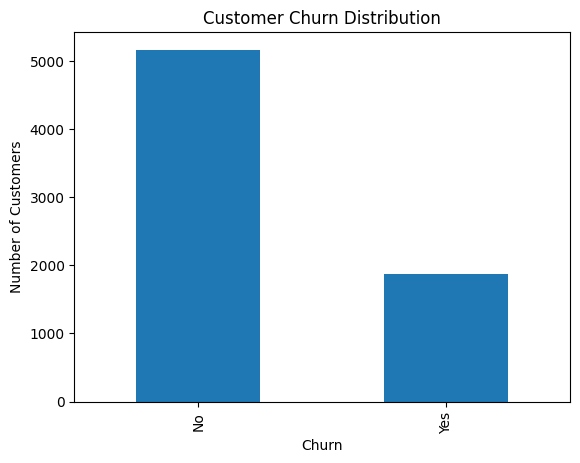

In [8]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

2️⃣ Churn vs Tenure

Purpose: Check whether long-term customers churn less.

Low tenure → higher churn

High tenure → lower churn

Customers who have stayed with the company for a long time are generally more loyal, while new customers are more likely to leave.

--> Customers with shorter tenure tend to churn more often.

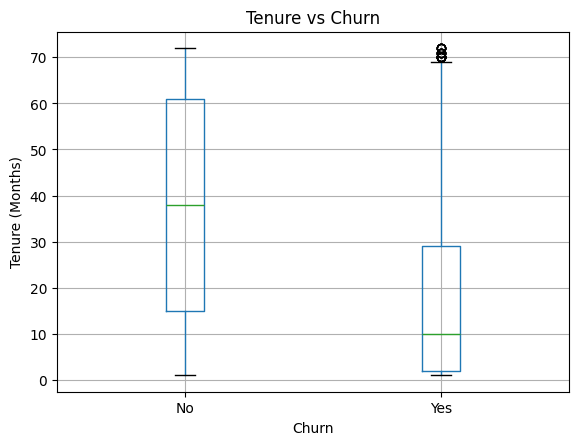

In [ ]:
df.boxplot(column='tenure', by='Churn')

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

3️⃣ Churn vs Contract Type

Purpose: Check whether contract type influences churn.

Customers with month-to-month contracts churn much more often than customers with long-term contracts.

--> Month-to-month contracts usually have the highest churn rate.

Business insight: Encourage long-term contracts

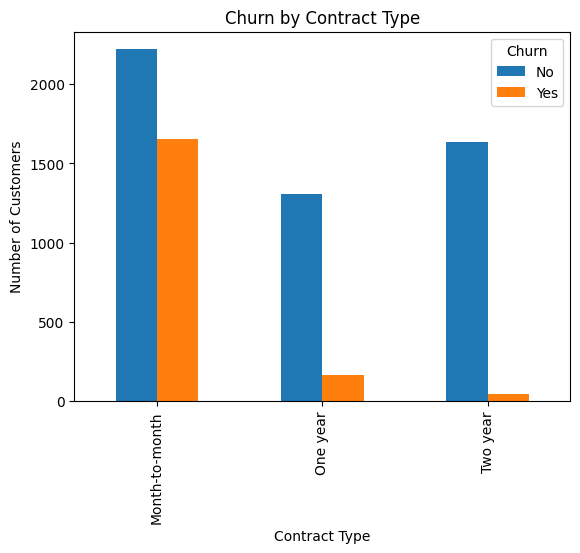

In [ ]:
contract_churn = df.groupby('Contract')['Churn'].value_counts().unstack()

contract_churn.plot(kind='bar')

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

4️⃣ Churn vs Monthly Charges

Purpose: Check if price influences churn.

Higher monthly charges → higher churn probability

Customers paying higher monthly charges may be more sensitive to price or more likely to switch to competitors.

--> Customers paying higher monthly charges may be more likely to leave.

Business action: Offer discounts to high-risk customers

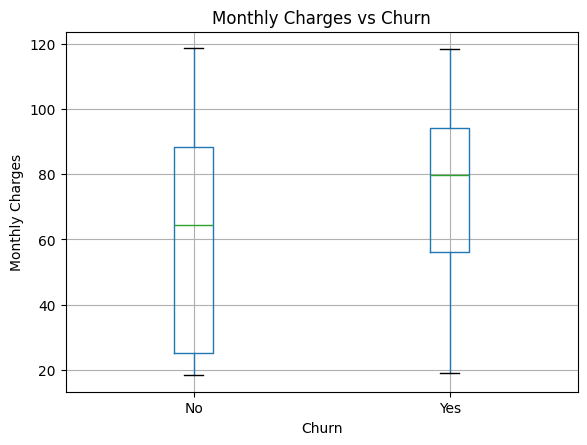

In [ ]:
df.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Which variable do you think is the strongest predictor of churn?

Modeling → Feature Importance

EDA leads to modeling, which is a key concept in Data Mining.


## 4. Data Preparation

1️⃣ Handling Missing Values

Some rows contain blank strings instead of numbers.

In [ ]:
df["TotalCharges"]

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

errors="coerce" → converts invalid values to NaN

dropna() → removes rows with missing values

2️⃣ Encoding Categorical Variables

Example categorical variables:

Contract -->
Month-to-Month, One Year

PaymentMethod -->
Credit card, Bank transfer

In [9]:

from sklearn.preprocessing import LabelEncoder

df = df.drop('customerID', axis=1)
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In this step we convert all categorical variables into numbers because machine learning algorithms cannot process text. We also remove the customer ID column because it does not help predict churn.

3️⃣ Train/Test Split

Training set (70%) --> used to learn patterns

Test set (30%) --> used to evaluate model

In [ ]:

X = df.drop('Churn', axis=1)
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


X = features

y = target variable

4️⃣ Preparing the Dataset for Modeling

X_train → training features;
y_train → training labels

X_test  → testing features;
y_test  → testing labels

## 5. Modeling

1️⃣Training the Churn Model


In [ ]:

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3)

## 6. Evaluation

In [ ]:

pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1549
           1       0.65      0.35      0.45       561

    accuracy                           0.78      2110
   macro avg       0.73      0.64      0.66      2110
weighted avg       0.76      0.78      0.75      2110



0 = No Churn

1 = Churn

Most customers do not churn. The dataset is imbalanced.

## 7. Feature Importance

Feature importance measures how much each input variable contributes to the model's prediction.

In [ ]:

import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)


,0
Contract,0.633894
MonthlyCharges,0.179925
tenure,0.175776
TotalCharges,0.010405
Partner,0.000000
gender,0.000000
SeniorCitizen,0.000000
InternetService,0.000000
Dependents,0.000000
PhoneService,0.000000


Which variables influence the churn prediction the most?
Contract type is the strongest predictor of customer churn.
This matches the EDA visualization we saw earlier: -->
Month-to-month contracts → higher churn

The model suggests that contract type, monthly charges, and customer tenure are the main drivers of churn.

Telecom company should focus on:
*   encouraging long-term contracts
*   supporting new customers
*   reviewing pricing plans

## 8. Decision Tree Visualization

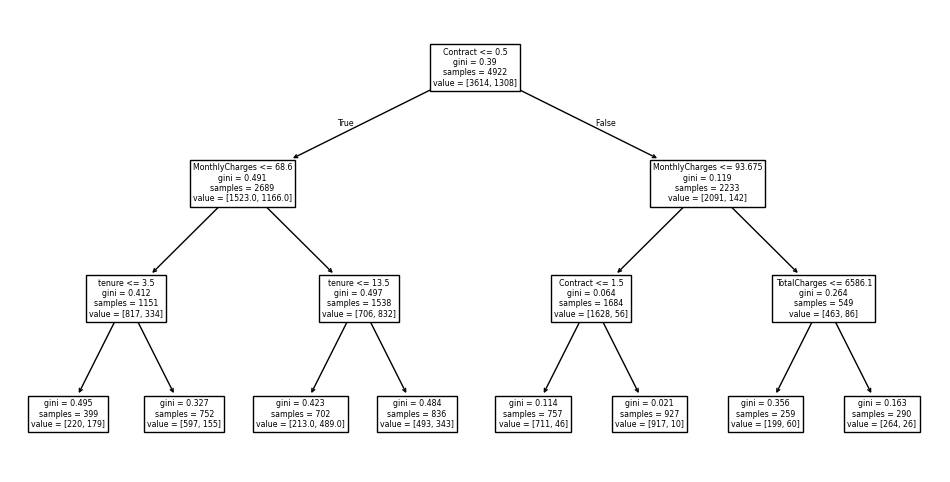

In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X.columns)
plt.show()


The model first checks the contract type. If the customer has a month-to-month contract, the model continues checking features like monthly charges and tenure. These rules help the model identify groups of customers with higher churn risk.

[Text(0.5, 0.875, 'Contract <= 0.5\ngini = 0.39\nsamples = 4922\nvalue = [3614, 1308]\nclass = No Churn'),
 Text(0.25, 0.625, 'MonthlyCharges <= 68.6\ngini = 0.491\nsamples = 2689\nvalue = [1523.0, 1166.0]\nclass = No Churn'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'tenure <= 3.5\ngini = 0.412\nsamples = 1151\nvalue = [817, 334]\nclass = No Churn'),
 Text(0.0625, 0.125, 'gini = 0.495\nsamples = 399\nvalue = [220, 179]\nclass = No Churn'),
 Text(0.1875, 0.125, 'gini = 0.327\nsamples = 752\nvalue = [597, 155]\nclass = No Churn'),
 Text(0.375, 0.375, 'tenure <= 13.5\ngini = 0.497\nsamples = 1538\nvalue = [706, 832]\nclass = Churn'),
 Text(0.3125, 0.125, 'gini = 0.423\nsamples = 702\nvalue = [213.0, 489.0]\nclass = Churn'),
 Text(0.4375, 0.125, 'gini = 0.484\nsamples = 836\nvalue = [493, 343]\nclass = No Churn'),
 Text(0.75, 0.625, 'MonthlyCharges <= 93.675\ngini = 0.119\nsamples = 2233\nvalue = [2091, 142]\nclass = No Churn'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 

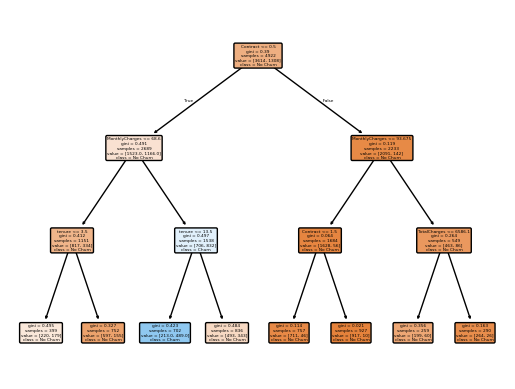

In [ ]:
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    rounded=True
)

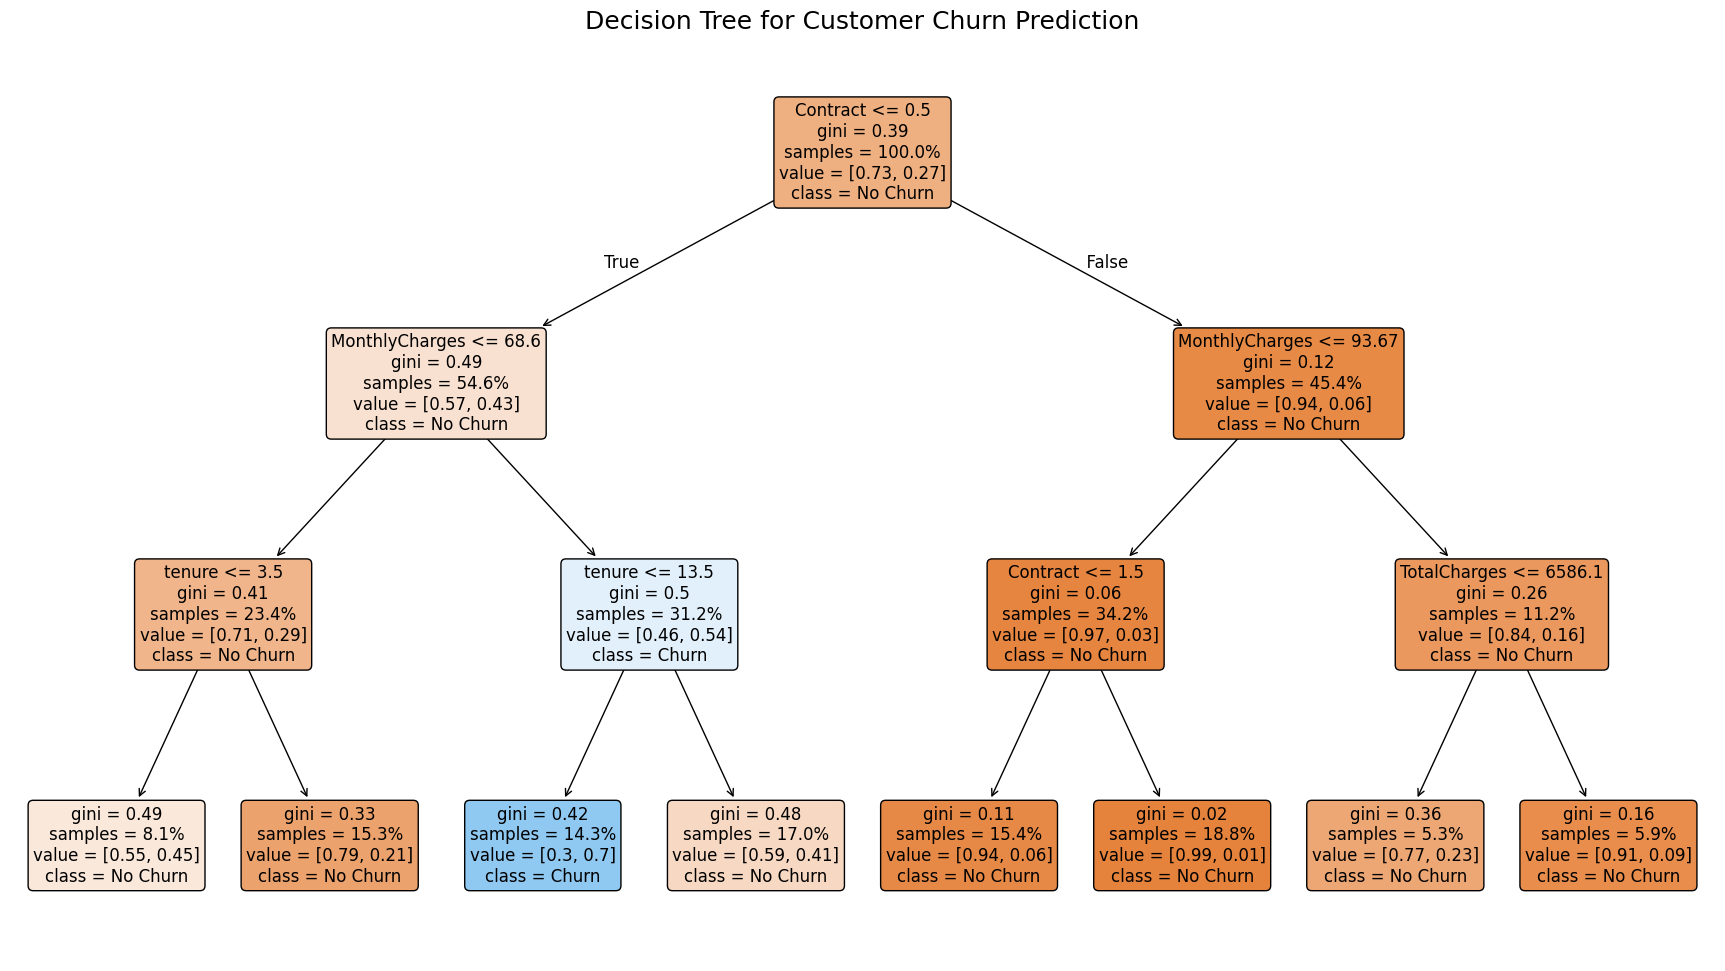

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=12,
    proportion=True,
    precision=2
)

plt.title("Decision Tree for Customer Churn Prediction", fontsize=18)

plt.show()